In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# set a clean, publication-friendly style and font sizes
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

In [2]:
df = pd.read_csv('training_history.csv')
df.head()

,epoch,loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate
0,1,0.470056,0.805476,0.013560,1.0,0.0001
1,2,0.123910,0.955476,0.010098,1.0,0.0001
2,3,0.090059,0.968333,0.000965,1.0,0.0001
3,4,0.118471,0.969286,0.002794,1.0,0.0001
4,5,0.065999,0.978810,0.000478,1.0,0.0001


## Figure: Training history (loss, accuracy, learning rate, gaps)

This figure shows the model training progress across epochs. The left column shows loss (training and validation), the right column shows accuracy (training and validation). The second row shows the learning rate schedule (log scale) and the train-vs-validation gaps for loss and accuracy.

For publication: export the figure at 300 DPI or as a vector PDF. Use the saved files generated by the following cells (PNG + PDF) and crop/bbox if needed. Axes are labeled with 'Epoch' on the x-axis and appropriate y-axis labels. Legends and gridlines are included for clarity.

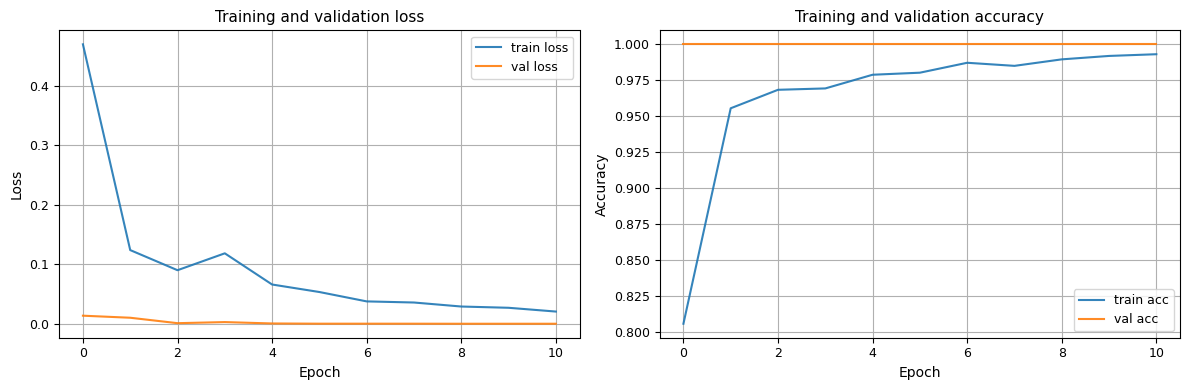

In [3]:
# Simple side-by-side plots: loss and accuracy (publication-ready)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# Loss subplot
df[['loss', 'val_loss']].plot(ax=ax[0], grid=True, linewidth=1.5, alpha=0.9)
ax[0].set_title('Training and validation loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend(['train loss', 'val loss'])
# Accuracy subplot
df[['sparse_categorical_accuracy', 'val_sparse_categorical_accuracy']].plot(ax=ax[1], grid=True, linewidth=1.5, alpha=0.9)
ax[1].set_title('Training and validation accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend(['train acc', 'val acc'])
fig.tight_layout()
# Save high-resolution files for publication (PNG + PDF)
fig.savefig('training_history_simple.png', dpi=300, bbox_inches='tight')
fig.savefig('training_history_simple.pdf', bbox_inches='tight')
plt.show()

Summary metrics: {'best_val_accuracy_epoch': 1, 'best_val_accuracy': 1.0, 'best_val_loss_epoch': 9, 'best_val_loss': 1.355646645606612e-06, 'final_train_loss': 0.0205129031091928, 'final_val_loss': 1.243822498508962e-05, 'final_train_acc': 0.9930952191352844, 'final_val_acc': 1.0}
Top 3 epochs by val accuracy:
   epoch  val_sparse_categorical_accuracy  val_loss
0      1                              1.0  0.013560
1      2                              1.0  0.010098
2      3                              1.0  0.000965

Top 3 epochs by lowest val loss:
    epoch  val_loss  val_sparse_categorical_accuracy
8       9  0.000001                              1.0
9      10  0.000009                              1.0
10     11  0.000012                              1.0

Percent change (first -> last):
loss: -95.64%
val_loss: -99.91%
train acc: 23.29%
val acc: 0.00%


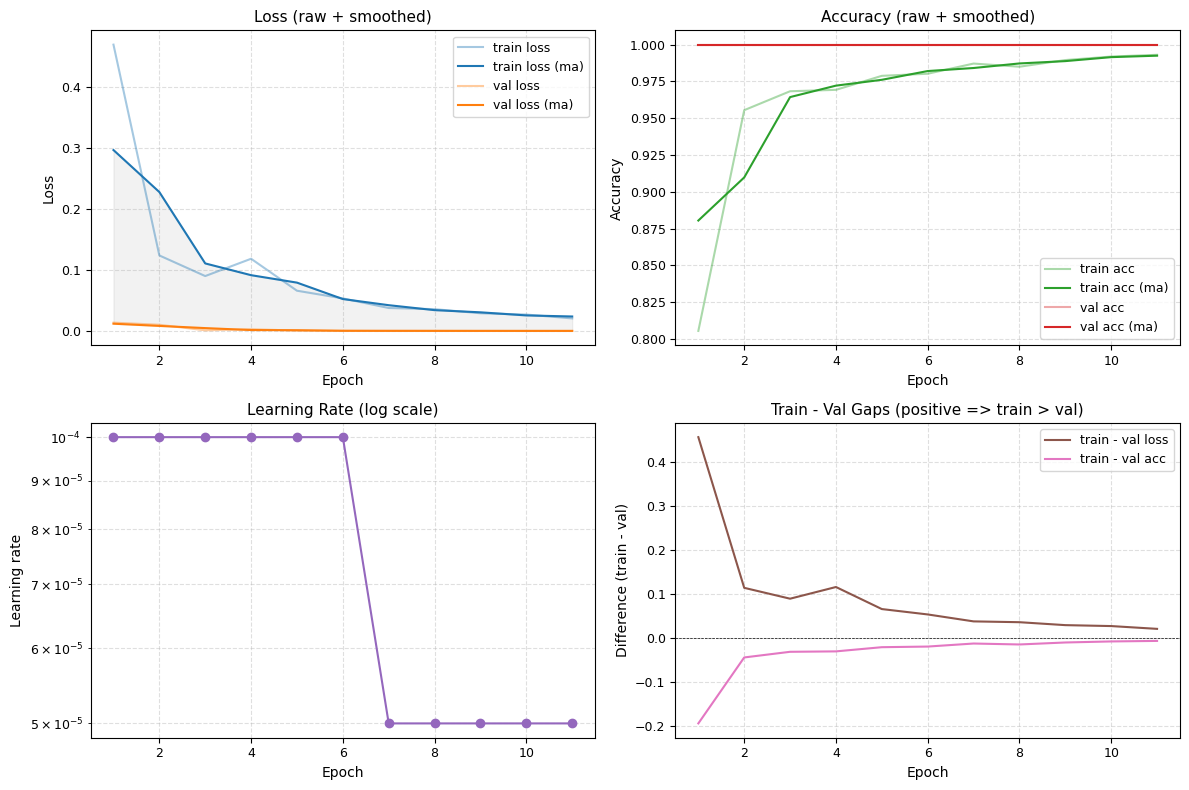

In [4]:
# quick additional analyses and visualizations for training history (new cell)

def smooth(s, window=3):
    return s.rolling(window=window, center=True, min_periods=1).mean()

# add smoothed columns
df['loss_ma'] = smooth(df['loss'], window=3)
df['val_loss_ma'] = smooth(df['val_loss'], window=3)
df['acc_ma'] = smooth(df['sparse_categorical_accuracy'], window=3)
df['val_acc_ma'] = smooth(df['val_sparse_categorical_accuracy'], window=3)

# summary statistics and key epochs
best_val_acc_idx = df['val_sparse_categorical_accuracy'].idxmax()
best_val_loss_idx = df['val_loss'].idxmin()
summary = {
    'best_val_accuracy_epoch': int(df.loc[best_val_acc_idx, 'epoch']),
    'best_val_accuracy': float(df.loc[best_val_acc_idx, 'val_sparse_categorical_accuracy']),
    'best_val_loss_epoch': int(df.loc[best_val_loss_idx, 'epoch']),
    'best_val_loss': float(df.loc[best_val_loss_idx, 'val_loss']),
    'final_train_loss': float(df['loss'].iloc[-1]),
    'final_val_loss': float(df['val_loss'].iloc[-1]),
    'final_train_acc': float(df['sparse_categorical_accuracy'].iloc[-1]),
    'final_val_acc': float(df['val_sparse_categorical_accuracy'].iloc[-1]),
}
print("Summary metrics:", summary)

# top-3 epochs by val accuracy and by lowest val loss
print("Top 3 epochs by val accuracy:")
print(df.nlargest(3, 'val_sparse_categorical_accuracy')[['epoch', 'val_sparse_categorical_accuracy', 'val_loss']])
print("\nTop 3 epochs by lowest val loss:")
print(df.nsmallest(3, 'val_loss')[['epoch', 'val_loss', 'val_sparse_categorical_accuracy']])

# percent change from first to last epoch
def pct_change(col):
    return 100.0 * (df[col].iloc[-1] - df[col].iloc[0]) / abs(df[col].iloc[0])
print("\nPercent change (first -> last):")
print("loss:", f"{pct_change('loss'):.2f}%")
print("val_loss:", f"{pct_change('val_loss'):.2f}%")
print("train acc:", f"{pct_change('sparse_categorical_accuracy'):.2f}%")
print("val acc:", f"{pct_change('val_sparse_categorical_accuracy'):.2f}%")

# plotting: smoothed metrics, learning rate, and train/val gaps (publication-ready)
fig2, axs = plt.subplots(2, 2, figsize=(12, 8))
x = df['epoch']

# Loss (raw + smoothed) with gap shading
axs[0,0].plot(x, df['loss'], label='train loss', color='C0', alpha=0.4)
axs[0,0].plot(x, df['loss_ma'], label='train loss (ma)', color='C0')
axs[0,0].plot(x, df['val_loss'], label='val loss', color='C1', alpha=0.4)
axs[0,0].plot(x, df['val_loss_ma'], label='val loss (ma)', color='C1')
axs[0,0].fill_between(x, df['loss_ma'], df['val_loss_ma'], color='gray', alpha=0.1)
axs[0,0].set_title('Loss (raw + smoothed)')
axs[0,0].set_xlabel('Epoch')
axs[0,0].set_ylabel('Loss')
axs[0,0].grid(True, linestyle='--', alpha=0.4)
axs[0,0].legend()

# Accuracy (raw + smoothed)
axs[0,1].plot(x, df['sparse_categorical_accuracy'], label='train acc', color='C2', alpha=0.4)
axs[0,1].plot(x, df['acc_ma'], label='train acc (ma)', color='C2')
axs[0,1].plot(x, df['val_sparse_categorical_accuracy'], label='val acc', color='C3', alpha=0.4)
axs[0,1].plot(x, df['val_acc_ma'], label='val acc (ma)', color='C3')
axs[0,1].set_title('Accuracy (raw + smoothed)')
axs[0,1].set_xlabel('Epoch')
axs[0,1].set_ylabel('Accuracy')
axs[0,1].grid(True, linestyle='--', alpha=0.4)
axs[0,1].legend()

# Learning rate schedule
axs[1,0].plot(x, df['learning_rate'], marker='o', color='C4')
axs[1,0].set_yscale('log')
axs[1,0].set_title('Learning Rate (log scale)')
axs[1,0].set_xlabel('Epoch')
axs[1,0].set_ylabel('Learning rate')
axs[1,0].grid(True, which='both', linestyle='--', alpha=0.4)

# Gaps: train - val for loss and accuracy
axs[1,1].plot(x, df['loss'] - df['val_loss'], label='train - val loss', color='C5')
axs[1,1].plot(x, df['sparse_categorical_accuracy'] - df['val_sparse_categorical_accuracy'],
              label='train - val acc', color='C6')
axs[1,1].axhline(0, color='k', linewidth=0.5, linestyle='--')
axs[1,1].set_title('Train - Val Gaps (positive => train > val)')
axs[1,1].set_xlabel('Epoch')
axs[1,1].set_ylabel('Difference (train - val)')
axs[1,1].grid(True, linestyle='--', alpha=0.4)
axs[1,1].legend()

fig2.tight_layout()
# Save high-resolution figure for publication
fig2.savefig('training_history_full.png', dpi=300, bbox_inches='tight')
fig2.savefig('training_history_full.pdf', bbox_inches='tight')
plt.show()

# Suggestions based on analysis
# - If val_loss stops decreasing but train loss keeps decreasing, consider stronger regularization or early stopping.
# - If val_acc is already saturated at 1.0, check for data leakage or overfitting; maybe reduce model capacity or increase data augmentation.
# - Use the learning rate plot to decide if LR scheduling is aggressive or too slow.

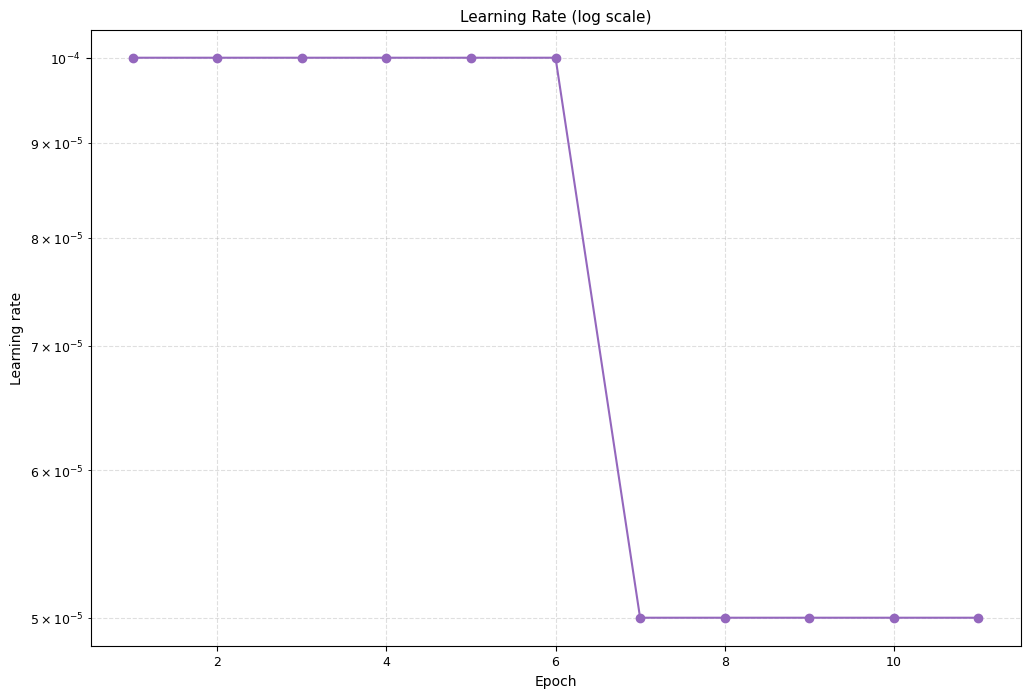

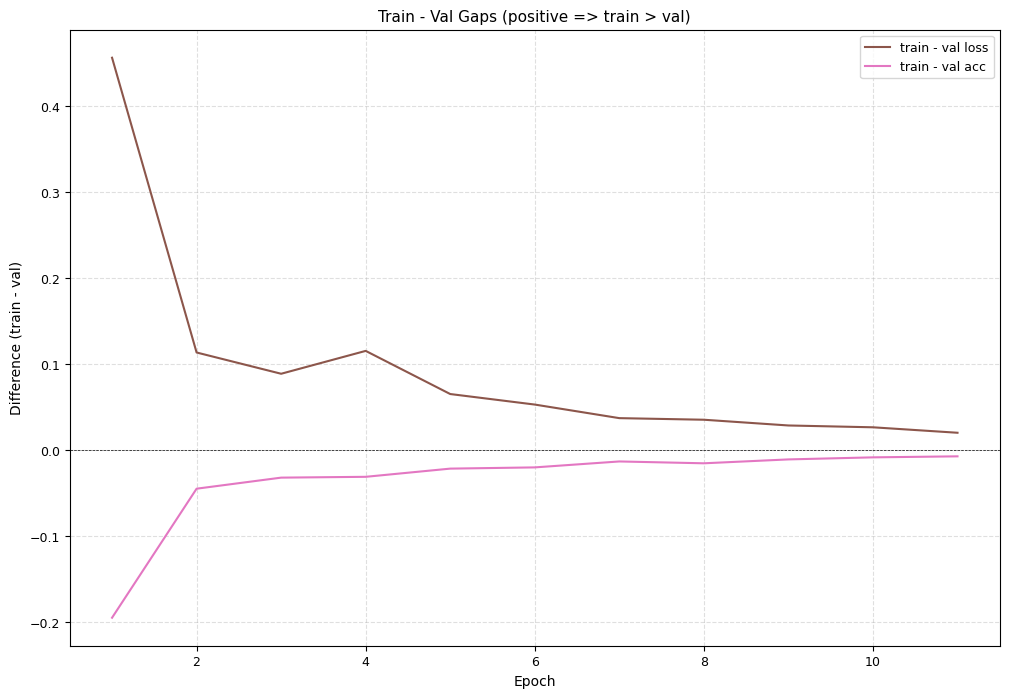

In [13]:

plt.figure(figsize=(12,8))
plt.plot(x, df['learning_rate'], marker='o', color='C4')
plt.yscale('log')
plt.title('Learning Rate (log scale)')
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(12,8))
plt.plot(x, df['loss'] - df['val_loss'], label='train - val loss', color='C5')
plt.plot(x, df['sparse_categorical_accuracy'] - df['val_sparse_categorical_accuracy'],
         label='train - val acc', color='C6')
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.title('Train - Val Gaps (positive => train > val)')
plt.xlabel('Epoch')
plt.ylabel('Difference (train - val)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()